# Anomaly Pipeline

Single-notebook anomaly detection pipeline for Bahrain customs trade data. Merges what was previously four separate notebooks (Price_Anomaly, Trade_Pattern, CR_Profile, Mergefile) into one.

**Input**: any cleaned-format file produced by `Cleaning.ipynb`.

**Output**: `master_anomalies.csv` — one row per declaration with all anomaly signals, sub-scores, sub-levels, and a final composite level.

**Final-level rule**: `final_level = max(price_level, pattern_level, cr_profile_level)`. 

**Pipeline structure** (six PARTs):

1. PART 0 — Setup
2. PART 1 — Load & Prepare
3. PART 2 — Price Anomaly
4. PART 3 — Trade Pattern
5. PART 4 — CR Profile
6. PART 5 — Composite Scoring
7. PART 6 — Save Output

---

# PART 0 — Setup

Imports, paths, and configuration constants used throughout the pipeline.

In [34]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# For testing reasons don't run the cumulative csv 

# Parameters 
input_path = r"C:\Users\fawaz\Desktop\Project\outputs\dummy_2020_cleaned.csv"
year = "2024"
output_path = r"C:\Users\fawaz\Desktop\Project\outputs\master_anomalies.csv"

In [35]:
CLEANED_PATH = Path(input_path)
HS_MAP_PATH  = Path(r"C:\Users\fawaz\Desktop\mofne\HSCode_table_updated.xlsx")
OUTPUT_PATH  = Path(output_path)

In [36]:
# CR Profile rolling-window configuration
WINDOW_MONTHS         = 12
PORTFOLIO_LOOKBACK    = 24
MIN_HISTORY_FOR_PRICE = 3

print("Configuration:")
print(f"  Input file:              {CLEANED_PATH.name}")
print(f"  Output file:             {OUTPUT_PATH.name}")
print(f"  Rolling window (months): {WINDOW_MONTHS}")
print(f"  Portfolio lookback:      {PORTFOLIO_LOOKBACK}")
print(f"  Min history for price:   {MIN_HISTORY_FOR_PRICE}")

Configuration:
  Input file:              dummy_2020_cleaned.csv
  Output file:             master_anomalies.csv
  Rolling window (months): 12
  Portfolio lookback:      24
  Min history for price:   3


---

# PART 1 — Load & Prepare

Load the cleaned CSV once, sort by date (rolling computations downstream require this), and report basics.

In [37]:
df = pd.read_csv(CLEANED_PATH, low_memory=False, parse_dates=["declaration_date"])
df = df.sort_values("declaration_date").reset_index(drop=True)

print(f"Loaded: {df.shape}")
print(f"Date range: {df['declaration_date'].min().date()} to {df['declaration_date'].max().date()}")
print(f"Unique CRs: {df['active_cr'].nunique()}")
print(f"Median declarations per CR: {df['active_cr'].value_counts().median():.0f}")

df.head(2)

Loaded: (1000, 52)
Date range: 2020-01-01 to 2020-12-30
Unique CRs: 49
Median declarations per CR: 20


,item_id,declaration_id,year,customs_office_code,customs_office_name,regime,registration_serial,registration_number,reference_number,registration_date,...,is_reexport,trade_type,local_amount_clean,invoice_amount_clean,sup_amount_clean,net_weight_clean,gross_weight_clean,partner_country_code,active_cr,hs_desc
0,2020-2601-5-10181-1,2020-2601-5-10181,2020,2601,Dry Port - Hidd,IM,5,10181,31819,1/1/2020,...,False,Import,1555.19,4136.14,3.40,4372.13,4783.52,DE,CR_HASH_027,Gas oils for diesel engines
1,2020-2801-1-10074-1,2020-2801-1-10074,2020,2801,King Fahd Causeway,EX,1,10074,48229,1/1/2020,...,True,Re-export,0.45,1.19,3.53,20.21,22.62,DE,CR_HASH_009,Plastic bottles for packaging


In [ ]:
# Optional sampling — comment out or set SAMPLE_SIZE = None to disable.
# Sample was used to test since the MOFNE data was 2m rows
SAMPLE_SIZE = None  

if SAMPLE_SIZE is not None and len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    df = df.sort_values("declaration_date").reset_index(drop=True)
    print(f"Sampled to {len(df):,} rows")
    print(f"Date range: {df['declaration_date'].min().date()} to {df['declaration_date'].max().date()}")
    print(f"Unique CRs in sample: {df['active_cr'].nunique()}")
else:
    print(f"No sampling — running on full {len(df):,} rows")

No sampling — running on full 1,000 rows


---

# PART 2 — Price Anomaly

Detects rows whose declared unit price deviates from the same `(hs_clean, uom, regime)` peer group's median in log-space, using robust z-scoring (median + MAD) plus an IQR backstop.

**Output columns added to `df`**: `qty_by_uom`, `actual_unit_price`, `log_actual_unit_price`, `price_basis`, `is_valid_price`, `median`, `mad`, `q1`, `q3`, `iqr`, `count`, `robust_z`, `anomaly_score`, `iqr_low`, `iqr_high`, `iqr_flag`, `flag_level`.

## Step 2.1 — Helper Functions (price-specific)

In [39]:
def to_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace(",", "").strip()
    if s in ("", "nan", "None", "null", "NULL"):
        return np.nan
    try:
        return float(s)
    except Exception:
        return np.nan

def compute_mad(x):
    arr = pd.Series(x).dropna().to_numpy()
    if len(arr) == 0:
        return np.nan
    med = np.median(arr)
    return np.median(np.abs(arr - med))

def flag_level(z):
    if pd.isna(z):
        return "NORMAL"
    z = abs(z)
    if z >= 5:
        return "HIGH"
    elif z >= 3:
        return "MEDIUM"
    elif z >= 2:
        return "LOW"
    return "NORMAL"

def clean_hs_12(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    s = re.sub(r"\D", "", s)
    if len(s) == 0:
        return ""
    return s.ljust(12, "0")[:12]

## Step 2.2 — Load HS Code → UOM Mapping

In [40]:
hs_map = pd.read_excel(HS_MAP_PATH)
hs_map = hs_map.rename(columns={"HS Code": "hs_code_map", "Unit": "uom"})
hs_map["hs_clean"] = hs_map["hs_code_map"].apply(clean_hs_12)
hs_map["uom"] = hs_map["uom"].astype(str).str.strip().str.upper()
hs_map = hs_map[["hs_clean", "uom"]].drop_duplicates(subset=["hs_clean"])

df["hs_clean"] = df["hs_clean"].astype(str)
hs_map["hs_clean"] = hs_map["hs_clean"].astype(str)
df = df.merge(hs_map, on="hs_clean", how="left", suffixes=("", "_hsmap"))
print(f"UOM merge done. Rows: {len(df)}")
df[["hs_clean", "uom"]].head(3)

UOM merge done. Rows: 1000


,hs_clean,uom
0,271019210000,LTR
1,392330100000,NMB
2,392330100000,NMB


## Step 2.3 — Quantity by UOM

In [41]:
WEIGHT_UOMS = {"KGM", "KG", "GRM", "G"}
COUNT_UOMS  = {"NMB", "NO", "PCS", "PCE", "PRS"}
VOLUME_UOMS = {"LTR", "L", "ML", "MLT"}

def choose_qty(row):
    uom     = str(row.get("uom", "")).strip().upper()
    net_w   = row.get("net_weight_clean", np.nan)
    gross_w = row.get("gross_weight_clean", np.nan)
    sup_q   = row.get("sup_amount_clean", np.nan)

    if uom in WEIGHT_UOMS:
        if pd.notna(net_w) and net_w > 0: return net_w
        if pd.notna(sup_q) and sup_q > 0: return sup_q
    if uom in COUNT_UOMS:
        if pd.notna(sup_q) and sup_q > 0: return sup_q
        if pd.notna(net_w) and net_w > 0: return net_w
    if uom in VOLUME_UOMS:
        if pd.notna(gross_w) and gross_w > 0: return gross_w
        if pd.notna(sup_q) and sup_q > 0:     return sup_q
        if pd.notna(net_w) and net_w > 0:     return net_w
    if pd.notna(sup_q) and sup_q > 0:   return sup_q
    if pd.notna(net_w) and net_w > 0:   return net_w
    if pd.notna(gross_w) and gross_w > 0: return gross_w
    return np.nan

df["qty_by_uom"] = df.apply(choose_qty, axis=1)
df[["uom","sup_amount_clean","net_weight_clean","gross_weight_clean","qty_by_uom"]].head(5)

,uom,sup_amount_clean,net_weight_clean,gross_weight_clean,qty_by_uom
0,LTR,3.40,4372.13,4783.52,4783.52
1,NMB,3.53,20.21,22.62,3.53
2,NMB,4.53,802.03,922.42,4.53
3,NMB,0.63,204.01,219.93,0.63
4,NMB,3.30,164.76,178.30,3.30


## Step 2.4 — Actual Unit Price

In [42]:
df["actual_unit_price"] = df["local_amount_clean"] / df["qty_by_uom"]

df.loc[(df["qty_by_uom"] <= 0) | (df["local_amount_clean"] <= 0), "actual_unit_price"] = np.nan

mask_uom_missing   = df["uom"].isna() | (df["uom"].astype(str).str.strip() == "") | (df["uom"].astype(str).str.upper() == "NAN")
mask_price_missing = df["actual_unit_price"].isna()
mask_sup_valid     = df["sup_amount_clean"].notna() & (df["sup_amount_clean"] > 0)
mask_local_valid   = df["local_amount_clean"].notna() & (df["local_amount_clean"] > 0)

fallback_mask = mask_uom_missing & mask_price_missing & mask_sup_valid & mask_local_valid
df.loc[fallback_mask, "actual_unit_price"] = (
    df.loc[fallback_mask, "local_amount_clean"] / df.loc[fallback_mask, "sup_amount_clean"]
)

df["log_actual_unit_price"] = np.log1p(df["actual_unit_price"])

def price_unit_label(uom):
    uom = str(uom).strip().upper()
    if uom in WEIGHT_UOMS:  return "price_per_kg"
    elif uom in COUNT_UOMS: return "price_per_item"
    elif uom in VOLUME_UOMS: return "price_per_liter_gross_weight"
    else: return "price_per_fallback_unit"

df["price_basis"] = df["uom"].apply(price_unit_label)
df[["hs_clean","uom","qty_by_uom","actual_unit_price","price_basis"]].head(5)

,hs_clean,uom,qty_by_uom,actual_unit_price,price_basis
0,271019210000,LTR,4783.52,0.325114,price_per_liter_gross_weight
1,392330100000,NMB,3.53,0.127479,price_per_item
2,392330100000,NMB,4.53,4.448124,price_per_item
3,102211000000,NMB,0.63,40284.714286,price_per_item
4,850440009000,NMB,3.30,1025.909091,price_per_item


## Step 2.5 — Valid Price Filter

In [43]:
df["is_valid_price"] = (
    df["hs_clean"].str.len().eq(12) &
    df["local_amount_clean"].notna() &
    (df["local_amount_clean"] > 0) &
    df["qty_by_uom"].notna() &
    (df["qty_by_uom"] > 0) &
    df["actual_unit_price"].notna() &
    np.isfinite(df["actual_unit_price"]) &
    df["declaration_date"].notna() &
    df["regime"].notna()
)

print(f"Total rows:      {len(df)}")
print(f"Valid for price: {df['is_valid_price'].sum()}")
print(f"Coverage:        {round(df['is_valid_price'].mean()*100,2)}%")
print()
print(df.loc[df['is_valid_price'], 'trade_type'].value_counts(dropna=False))
print()
print(df.loc[df['is_valid_price'], 'price_basis'].value_counts(dropna=False))

Total rows:      1000
Valid for price: 954
Coverage:        95.4%

trade_type
Import       677
Re-export    277
Name: count, dtype: int64

price_basis
price_per_item                  754
price_per_kg                    101
price_per_liter_gross_weight     99
Name: count, dtype: int64


## Step 2.6 — Group Statistics (Median / MAD / IQR)

In [44]:
group_cols = ["hs_clean", "uom", "regime"]

def mad(x):
    x = pd.Series(x).dropna()
    if len(x) == 0: return np.nan
    med = np.median(x)
    return np.median(np.abs(x - med))

# Compute group stats on ONLY the valid-price rows
group_stats = (
    df[df["is_valid_price"]]
    .groupby(group_cols)["log_actual_unit_price"]
    .agg(
        count  = "size",
        median = "median",
        mad    = mad,
        q1     = lambda x: x.quantile(0.25),
        q3     = lambda x: x.quantile(0.75)
    )
    .reset_index()
)

group_stats["iqr"] = group_stats["q3"] - group_stats["q1"]
print(f"Group stats shape: {group_stats.shape}")
group_stats.head()

Group stats shape: (20, 9)


,hs_clean,uom,regime,count,median,mad,q1,q3,iqr
0,100630100000,KGM,EX,29,0.294281,0.078651,0.236620,0.395441,0.158821
1,100630100000,KGM,IM,72,0.328698,0.067679,0.270176,0.398601,0.128425
2,102211000000,NMB,EX,24,9.549318,0.697144,8.846104,10.187556,1.341452
3,102211000000,NMB,IM,61,10.013369,0.685568,9.327801,10.638441,1.310639
4,271019210000,LTR,EX,31,0.277386,0.077989,0.163969,0.332446,0.168477


## Step 2.7 — Anomaly Scoring

In [ ]:
df = df.merge(group_stats, on=group_cols, how="left")

# If MAD = 0, every row in the group has an identical price, so a robust
# z-score is undefined. Setting MAD to NaN there makes robust_z NaN for
# those rows (→ flag_level = NORMAL), which is the right behavior instead
# of inflating to ±infinity with epsilon.
df["mad_clean"] = df["mad"].replace(0, np.nan)

df["robust_z"] = (
    df["log_actual_unit_price"] - df["median"]
) / (1.4826 * df["mad_clean"])

df["anomaly_score"] = df["robust_z"].abs()

df["iqr_low"]  = df["q1"] - 1.5 * df["iqr"]
df["iqr_high"] = df["q3"] + 1.5 * df["iqr"]

df["iqr_flag"] = (
    (df["log_actual_unit_price"] < df["iqr_low"]) |
    (df["log_actual_unit_price"] > df["iqr_high"])
).fillna(False)

df["price_level"] = df["robust_z"].apply(flag_level)

# Lift NORMAL → LOW if IQR also flags it
mask_iqr_low = (df["iqr_flag"]) & (df["price_level"] == "NORMAL")
df.loc[mask_iqr_low, "price_level"] = "LOW"

# Rows that didn't pass the valid-price filter get NORMAL (no signal)
df.loc[~df["is_valid_price"], "price_level"] = "NORMAL"

# Cleanup NaN/Inf so the CSV is clean
df["median"]        = df["median"].fillna(df["log_actual_unit_price"])
df["mad"]           = df["mad"].fillna(0)
df["q1"]            = df["q1"].fillna(df["log_actual_unit_price"])
df["q3"]            = df["q3"].fillna(df["log_actual_unit_price"])
df["iqr"]           = df["iqr"].fillna(0)
df["robust_z"]      = df["robust_z"].replace([np.inf, -np.inf], np.nan).fillna(0)
df["anomaly_score"] = df["anomaly_score"].replace([np.inf, -np.inf], np.nan).fillna(0)
df["iqr_low"]       = df["iqr_low"].fillna(df["log_actual_unit_price"])
df["iqr_high"]      = df["iqr_high"].fillna(df["log_actual_unit_price"])

if "mad_clean" in df.columns:
    df = df.drop(columns=["mad_clean"])

print("anomaly_score stats:")
print(df["anomaly_score"].describe())
print()
print("price_level distribution:")
print(df["price_level"].value_counts())

anomaly_score stats:
count    1000.000000
mean        0.839967
std         0.873210
min         0.000000
25%         0.273527
50%         0.645686
75%         1.113365
max         9.832893
Name: anomaly_score, dtype: float64

price_level distribution:
price_level
NORMAL    921
LOW        53
MEDIUM     20
HIGH        6
Name: count, dtype: int64


## Step 2.8 — Visualizations (Price)

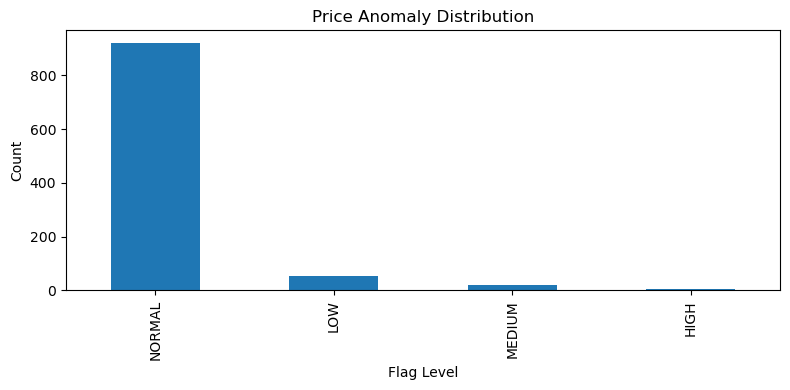

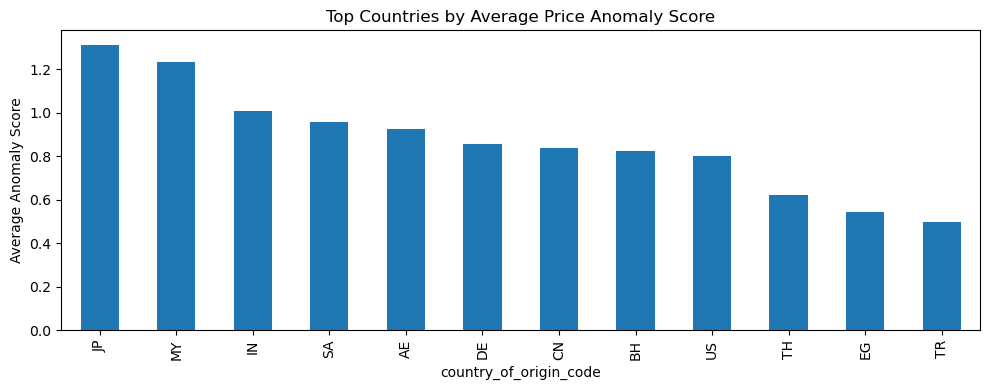

In [46]:
# Flag distribution
flag_counts = df["price_level"].value_counts(dropna=False)
plt.figure(figsize=(8,4))
flag_counts.plot(kind="bar")
plt.title("Price Anomaly Distribution")
plt.xlabel("Flag Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Top countries by anomaly score
origin_risk = (
    df[df["is_valid_price"]]
    .groupby("country_of_origin_code")["anomaly_score"]
    .mean().sort_values(ascending=False).head(15)
)
plt.figure(figsize=(10,4))
origin_risk.plot(kind="bar")
plt.title("Top Countries by Average Price Anomaly Score")
plt.ylabel("Average Anomaly Score")
plt.tight_layout()
plt.show()

---

# PART 3 — Trade Pattern

Detects rare partner countries, rare routes, and sudden monthly volume spikes (burstiness) for `(hs6, regime, partner)` and `(hs6, regime, origin, export, destination)` combinations.

**Output columns added to `df`**: `pattern_partner`, `pattern_route`, `is_valid_pattern`, `partner_count`, `partner_probability`, `partner_rarity_raw`, `route_count`, `route_probability`, `route_rarity_raw`, `active_months`, `month_mean`, `month_std`, `month_max`, `burstiness_raw`, `partner_rarity_score`, `route_rarity_score`, `burstiness_score`, `trade_pattern_score`, `pattern_level`, `trade_pattern_flag`.

## Step 3.1 — Helper Functions (pattern-specific)

In [47]:
def minmax_scale(s):
    s = pd.Series(s)
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)

def pattern_level_from_score(score):
    if pd.isna(score): return "NORMAL"
    if score >= 85:    return "HIGH"
    elif score >= 75:  return "MEDIUM"
    elif score >= 45:  return "LOW"
    return "NORMAL"


## Step 3.2 — Build Pattern Keys

In [48]:
df["pattern_partner"] = (
    df["hs6"].fillna("").astype(str) + "|" +
    df["regime"].fillna("").astype(str) + "|" +
    df["partner_country_code"].fillna("").astype(str)
)

df["pattern_route"] = (
    df["hs6"].fillna("").astype(str) + "|" +
    df["regime"].fillna("").astype(str) + "|" +
    df["country_of_origin_code"].fillna("").astype(str) + "|" +
    df["country_of_export_code"].fillna("").astype(str) + "|" +
    df["country_of_destination_code"].fillna("").astype(str)
)

df[["hs6","regime","trade_type","partner_country_code","pattern_partner","pattern_route"]].head(3)

,hs6,regime,trade_type,partner_country_code,pattern_partner,pattern_route
0,271019,IM,Import,DE,271019|IM|DE,271019|IM|DE|DE|BH
1,392330,EX,Re-export,DE,392330|EX|DE,392330|EX|BH|BH|DE
2,392330,IM,Import,US,392330|IM|US,392330|IM|US|JP|BH


## Step 3.3 — Filter Valid Rows for Pattern Analysis

In [49]:
df["is_valid_pattern"] = (
    df["hs6"].astype(str).str.len().eq(6) &
    df["regime"].notna() &
    df["declaration_date"].notna() &
    df["partner_country_code"].notna()
)

print(f"Total rows:                      {len(df)}")
print(f"Valid rows for pattern analysis: {df['is_valid_pattern'].sum()}")
print(f"Coverage:                        {round(df['is_valid_pattern'].mean()*100,2)}%")
print()
print(df.loc[df['is_valid_pattern'], 'trade_type'].value_counts(dropna=False))

Total rows:                      1000
Valid rows for pattern analysis: 954
Coverage:                        95.4%

trade_type
Import       677
Re-export    277
Name: count, dtype: int64


## Step 3.4 — Partner Pattern Statistics

In [50]:
partner_cols = ["hs6", "regime", "partner_country_code"]

partner_stats = (
    df[df["is_valid_pattern"]]
    .groupby(partner_cols)
    .size()
    .reset_index(name="partner_count")
)

total_partner_rows = partner_stats["partner_count"].sum()
partner_stats["partner_probability"] = partner_stats["partner_count"] / total_partner_rows
partner_stats["partner_rarity_raw"]  = -np.log(partner_stats["partner_probability"])

print(f"Partner pattern groups: {len(partner_stats)}")
partner_stats.head()

Partner pattern groups: 154


,hs6,regime,partner_country_code,partner_count,partner_probability,partner_rarity_raw
0,100630,EX,AE,5,0.005241,5.251226
1,100630,EX,CN,7,0.007338,4.914754
2,100630,EX,DE,1,0.001048,6.860664
3,100630,EX,IN,2,0.002096,6.167516
4,100630,EX,JP,4,0.004193,5.474369


## Step 3.5 — Route Pattern Statistics

In [51]:
route_cols = ["hs6", "regime", "country_of_origin_code",
              "country_of_export_code", "country_of_destination_code"]

route_stats = (
    df[df["is_valid_pattern"]]
    .groupby(route_cols)
    .size()
    .reset_index(name="route_count")
)

total_route_rows = route_stats["route_count"].sum()
route_stats["route_probability"] = route_stats["route_count"] / total_route_rows
route_stats["route_rarity_raw"]  = -np.log(route_stats["route_probability"])

print(f"Route pattern groups: {len(route_stats)}")
route_stats.head()

Route pattern groups: 287


,hs6,regime,country_of_origin_code,country_of_export_code,country_of_destination_code,route_count,route_probability,route_rarity_raw
0,100630,EX,BH,BH,AE,5,0.005241,5.251226
1,100630,EX,BH,BH,CN,7,0.007338,4.914754
2,100630,EX,BH,BH,DE,1,0.001048,6.860664
3,100630,EX,BH,BH,IN,2,0.002096,6.167516
4,100630,EX,BH,BH,JP,4,0.004193,5.474369


## Step 3.6 — Burstiness (Monthly Volume Spikes)

Burstiness compares the peak month to the average month for each `(hs6, regime, partner)` combination. Steady relationships score 1.0; relationships with one spike month score >> 1.0.

In [52]:
monthly_partner = (
    df[df["is_valid_pattern"]]
    .groupby(partner_cols + ["year_month"])
    .size()
    .reset_index(name="month_count")
)
partner_month_stats = (
    monthly_partner
    .groupby(partner_cols)["month_count"]
    .agg(active_months="size", month_mean="mean", month_std="std", month_max="max")
    .reset_index()
)
partner_month_stats["month_std"] = partner_month_stats["month_std"].fillna(0)

# Burstiness = peak month / average month. Guarded against month_mean = 0.
partner_month_stats["burstiness_raw"] = (
    partner_month_stats["month_max"] / partner_month_stats["month_mean"].replace(0, np.nan)
).fillna(1.0)

print(f"Partner-month groups: {len(partner_month_stats)}")
print(f"burstiness_raw stats:")
print(partner_month_stats["burstiness_raw"].describe())
partner_month_stats.head()

Partner-month groups: 154
burstiness_raw stats:
count    154.000000
mean       1.337610
std        0.430248
min        1.000000
25%        1.000000
50%        1.000000
75%        1.627273
max        2.571429
Name: burstiness_raw, dtype: float64


,hs6,regime,partner_country_code,active_months,month_mean,month_std,month_max,burstiness_raw
0,100630,EX,AE,4,1.25,0.500000,2,1.600000
1,100630,EX,CN,5,1.40,0.547723,2,1.428571
2,100630,EX,DE,1,1.00,0.000000,1,1.000000
3,100630,EX,IN,2,1.00,0.000000,1,1.000000
4,100630,EX,JP,4,1.00,0.000000,1,1.000000


## Step 3.7 — Merge Stats & Score

In [53]:
# Merge stats back onto df (left-join; rows that don't match get NaN, handled below)
df = df.merge(partner_stats,       on=partner_cols, how="left")
df = df.merge(route_stats,         on=route_cols,   how="left")
df = df.merge(partner_month_stats, on=partner_cols, how="left")

# Score on 0-100 scale via min-max normalization of the rarity / burstiness columns.
# Rows that failed the valid-pattern filter will have NaN raw values → 0 score.
df["partner_rarity_score"] = (minmax_scale(df["partner_rarity_raw"]) * 100).fillna(0)
df["route_rarity_score"]   = (minmax_scale(df["route_rarity_raw"])   * 100).fillna(0)
df["burstiness_score"]     = (minmax_scale(df["burstiness_raw"])     * 100).fillna(0)

df["trade_pattern_score"] = (
    0.50 * df["partner_rarity_score"] +
    0.35 * df["route_rarity_score"]   +
    0.15 * df["burstiness_score"]
)

df["pattern_level"] = df["trade_pattern_score"].apply(pattern_level_from_score)

# Rows that didn't pass the valid-pattern filter get NORMAL
df.loc[~df["is_valid_pattern"], "pattern_level"] = "NORMAL"

df["trade_pattern_flag"] = (df["pattern_level"] != "NORMAL").astype(int)

print("pattern_level distribution:")
print(df["pattern_level"].value_counts())

df[["hs6","regime","trade_type","partner_country_code",
    "partner_rarity_score","route_rarity_score","burstiness_score",
    "trade_pattern_score","pattern_level"]].head()

pattern_level distribution:
pattern_level
NORMAL    669
LOW       306
HIGH       25
Name: count, dtype: int64


,hs6,regime,trade_type,partner_country_code,partner_rarity_score,route_rarity_score,burstiness_score,trade_pattern_score,pattern_level
0,271019,IM,Import,DE,58.397080,77.232975,0.000000,56.230082,LOW
1,392330,EX,Re-export,DE,100.000000,100.000000,0.000000,85.000000,HIGH
2,392330,IM,Import,US,30.899046,100.000000,70.000000,60.949523,LOW
3,102211,IM,Import,TH,100.000000,100.000000,0.000000,85.000000,HIGH
4,850440,IM,Import,CN,11.636907,11.051725,56.937799,18.227227,NORMAL


## Step 3.8 — Visualizations (Pattern)

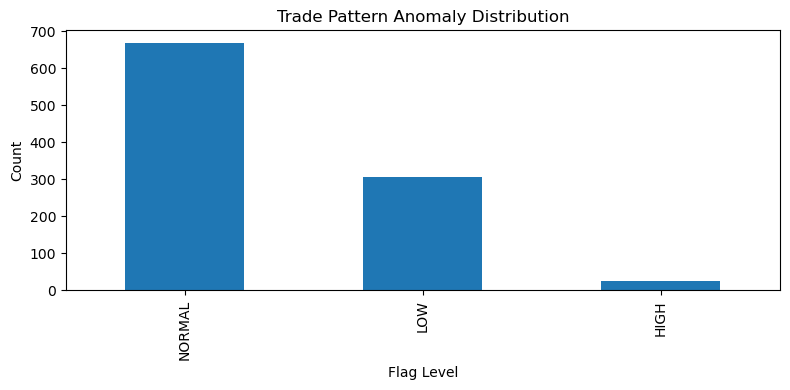

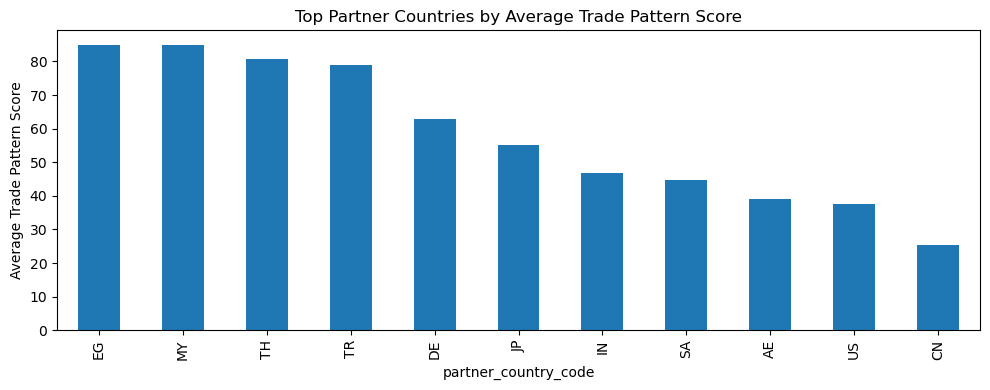

In [54]:
flag_counts = df["pattern_level"].value_counts()
plt.figure(figsize=(8,4))
flag_counts.plot(kind="bar")
plt.title("Trade Pattern Anomaly Distribution")
plt.xlabel("Flag Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

country_risk = (
    df[df["is_valid_pattern"]]
    .groupby("partner_country_code")["trade_pattern_score"]
    .mean().sort_values(ascending=False).head(20)
)
plt.figure(figsize=(10,4))
country_risk.plot(kind="bar")
plt.title("Top Partner Countries by Average Trade Pattern Score")
plt.ylabel("Average Trade Pattern Score")
plt.tight_layout()
plt.show()

---

# PART 4 — CR Profile

Builds a per-CR behavioral profile from the CR's own trading history and flags declarations that deviate from that CR's normal pattern. Five signals computed across rolling windows:

1. **Per-CR price anomaly (dual layer)** — own-history z + peer-market z
2. **HS burstiness within a CR** — sudden monthly spike for one CR's HS code
3. **HS frequency per CR** — months-active count + first-time-in-window flag
4. **Partner novelty per CR** — first-time / rare partners and CR-HS-partner combos
5. **Portfolio distance** — distance of this declaration's HS chapter from the CR's historical chapter mix

All signals use the rolling windows defined in PART 0. When a CR has insufficient history, signals return neutral values (0 / NaN / False).

## Step 4.1 — Helper Functions (CR-specific)

In [55]:
def cr_level_from_score(x):
    if pd.isna(x):
        return "NORMAL"
    if x >= 85: return "HIGH"
    if x >= 75: return "MEDIUM"
    if x >= 35: return "LOW"
    return "NORMAL"


def safe_z(value, baseline_series, min_n=MIN_HISTORY_FOR_PRICE):
    """Robust z = (value - median) / (1.4826 * MAD). Returns 0 if not enough history."""
    s = baseline_series.dropna()
    if len(s) < min_n:
        return 0.0
    med = s.median()
    mad = (s - med).abs().median()
    if mad == 0 or pd.isna(mad):
        return 0.0
    return float((value - med) / (1.4826 * mad))

## Step 4.2 — Signal 1: Per-CR Price Anomaly (Dual Layer)

Two complementary z-scores per row:

- **Own-history z**: how far is this declaration's price from this CR's own median for the same HS over the previous `WINDOW_MONTHS`. Catches a previously-consistent CR suddenly under- or over-invoicing.
- **Peer-market z**: how far is the price from the median price all *other* CRs paid for the same HS in the same year. Catches a CR that systematically prices off-market.

Both use robust statistics (median + MAD). Sign is preserved: negative = under, positive = over.

In [56]:
def compute_price_zscores(df_in: pd.DataFrame) -> pd.DataFrame:
    """Vectorized own-history + peer-market price z-scores using searchsorted."""
    out = df_in.copy()
    n = len(out)

    # ---- Own-history z ----
    own_z = np.zeros(n, dtype=float)

    # Build per-(cr, hs6) sorted arrays. Sort is by date but stable to preserve
    # tie-order from the original frame (which the loop relies on via enumerate).
    work = out[["active_cr", "hs6", "declaration_date", "actual_unit_price"]].copy()
    work["_orig_idx"] = np.arange(n)

    own_groups = work.groupby(["active_cr", "hs6"], sort=False)
    for (cr, hs), grp in tqdm(own_groups, total=own_groups.ngroups,
                              desc="  Own-history z", mininterval=1.0):
        # Note: groupby preserves insertion order within each group when sort=False.
        # The original loop processes rows in this same order via enumerate.
        idxs   = grp["_orig_idx"].to_numpy()
        dates  = pd.to_datetime(grp["declaration_date"]).to_numpy()
        prices = grp["actual_unit_price"].to_numpy()

        window_starts = (
            pd.to_datetime(grp["declaration_date"]) - pd.DateOffset(months=WINDOW_MONTHS)
        ).to_numpy()

        # For each row in this group, history = prior rows with date in
        # [window_starts[i], dates[i]). The original uses range(j) so the
        # ordering is positional, not strictly date-sorted. For dates that
        # are uniformly increasing this matches; for ties on the same day
        # within a group, both implementations agree because the loop's
        # range(j) and our positional searchsorted both consider only
        # strictly-prior positions.
        for i in range(len(idxs)):
            # Strictly-prior rows: positions 0..i-1, AND date strictly less than current
            # (matches original loop's `dates[j] >= window_start and dates[j] < current_date`)
            current_date = dates[i]
            history = prices[:i][
                (dates[:i] >= window_starts[i]) & (dates[:i] < current_date)
            ]
            history = history[~np.isnan(history)]
            if len(history) >= MIN_HISTORY_FOR_PRICE:
                med = np.median(history)
                mad = np.median(np.abs(history - med))
                if mad >= 1e-9 and not np.isnan(mad):
                    own_z[idxs[i]] = (prices[i] - med) / (1.4826 * mad)

    out["cr_price_z_own"] = own_z

    # ---- Peer-market z ----
    # For each (hs6, year), z of this row's price against all OTHER CRs' prices.
    # All rows of the same CR get the same z (against the same peer baseline).
    peer_z = np.zeros(n, dtype=float)

    peer_groups = out.groupby(["hs6", "year"], sort=False)
    for (hs, yr), grp in tqdm(peer_groups, total=peer_groups.ngroups,
                              desc="  Peer-market z", mininterval=1.0):
        prices = grp["actual_unit_price"].to_numpy()
        crs    = grp["active_cr"].to_numpy()
        idxs   = grp.index.to_numpy()

        unique_crs = np.unique(crs)

        for cr in unique_crs:
            self_mask = crs == cr
            peer_prices = prices[~self_mask]
            peer_prices = peer_prices[~np.isnan(peer_prices)]

            if len(peer_prices) < MIN_HISTORY_FOR_PRICE:
                continue

            med = np.median(peer_prices)
            mad = np.median(np.abs(peer_prices - med))
            if mad < 1e-9 or np.isnan(mad):
                continue

            self_idxs   = idxs[self_mask]
            self_prices = prices[self_mask]
            zs = (self_prices - med) / (1.4826 * mad)
            # out.index.get_indexer is O(N); but idxs are already integer positions
            # if the index is the default RangeIndex. Use positional assignment.
            peer_z[self_idxs] = zs

    out["cr_price_z_peer"] = peer_z

    combined_abs = np.maximum(np.abs(own_z), np.abs(peer_z))
    out["cr_price_severity"] = np.clip(combined_abs / 4.0 * 100, 0, 100)

    return out


df = compute_price_zscores(df)
print("Step 4.2 done.")
print(df[["cr_price_z_own", "cr_price_z_peer", "cr_price_severity"]].describe().round(2))
print()
print(f"Rows with non-zero own-history z: {(df['cr_price_z_own'] != 0).sum()}")
print(f"Rows with non-zero peer-market z: {(df['cr_price_z_peer'] != 0).sum()}")

  Own-history z:   0%|          | 0/434 [00:00<?, ?it/s]

  Peer-market z:   0%|          | 0/10 [00:00<?, ?it/s]

Step 4.2 done.
       cr_price_z_own  cr_price_z_peer  cr_price_severity
count         1000.00          1000.00            1000.00
mean             0.09             0.61              27.15
std              2.52             2.58              27.62
min            -33.20            -2.36               0.27
25%              0.00            -0.60               9.66
50%              0.00             0.01              17.99
75%              0.00             0.87              28.42
max             32.85            41.35             100.00

Rows with non-zero own-history z: 97
Rows with non-zero peer-market z: 1000


## Step 4.3 — Signal 2: HS Burstiness Within a CR

For each `(active_cr, hs6)` combination, ratio of current month's count to the rolling 12-month median. A combo doing 5/month every month gets ratio ≈ 1; a normally-quiet combo with one spike gets a high ratio. Distinguishes from Trade Pattern's burstiness (market-level) by being CR-level.

In [57]:
def compute_cr_burstiness(df_in: pd.DataFrame) -> pd.DataFrame:
    """Vectorized burstiness using searchsorted (exact calendar-month math).

    For each monthly count entry, find all PREVIOUS monthly entries within
    the calendar window (date - WINDOW_MONTHS, date), take median, divide.
    """
    out = df_in.copy()
    # Idempotency: drop any prior outputs from a previous run so .merge() won't collide
    out = out.drop(columns=["cr_burst_ratio", "cr_burst_severity"], errors="ignore")

    monthly = (
        out.groupby(["active_cr", "hs6", "year_month"])
        .size().reset_index(name="month_count")
    )
    monthly["year_month_dt"] = pd.to_datetime(monthly["year_month"], format="%Y-%m")
    monthly = monthly.sort_values(
        ["active_cr", "hs6", "year_month_dt"], kind="stable"
    ).reset_index(drop=True)

    n_monthly = len(monthly)
    burst = np.ones(n_monthly, dtype=float)

    # Per (cr, hs) group: build sorted arrays then use searchsorted for each entry
    # to find the prior entries within window. This matches calendar-month math exactly.
    burst_groups = monthly.groupby(["active_cr", "hs6"], sort=False)
    for (cr, hs), grp in tqdm(burst_groups, total=burst_groups.ngroups,
                              desc="  Burstiness", mininterval=1.0):
        idxs   = grp.index.to_numpy()
        dts    = grp["year_month_dt"].to_numpy()
        counts = grp["month_count"].to_numpy()

        # window_start[i] = dts[i] - WINDOW_MONTHS
        window_starts = (
            pd.to_datetime(grp["year_month_dt"]) - pd.DateOffset(months=WINDOW_MONTHS)
        ).to_numpy()

        for i in range(len(idxs)):
            # History: prior entries (j < i) with dts[j] >= window_starts[i]
            # Since dts is sorted, we can find the start with searchsorted.
            lo = np.searchsorted(dts, window_starts[i], side="left")
            history = counts[lo:i]
            if len(history) >= 2:
                base = np.median(history)
                if base > 0:
                    burst[idxs[i]] = counts[i] / base

    monthly["cr_burst_ratio"] = burst

    out = out.merge(
        monthly[["active_cr", "hs6", "year_month", "cr_burst_ratio"]],
        on=["active_cr", "hs6", "year_month"],
        how="left"
    )
    out["cr_burst_ratio"] = out["cr_burst_ratio"].fillna(1.0)
    out["cr_burst_severity"] = np.clip((out["cr_burst_ratio"] - 1) / 4.0 * 100, 0, 100)

    return out


df = compute_cr_burstiness(df)
print("Step 4.3 done.")
print(df[["cr_burst_ratio", "cr_burst_severity"]].describe().round(2))
print(f"Rows with burst ratio > 1: {(df['cr_burst_ratio'] > 1).sum()}")

  Burstiness:   0%|          | 0/434 [00:00<?, ?it/s]

Step 4.3 done.
       cr_burst_ratio  cr_burst_severity
count         1000.00            1000.00
mean             1.04               1.12
std              0.25               6.18
min              0.50               0.00
25%              1.00               0.00
50%              1.00               0.00
75%              1.00               0.00
max              3.00              50.00
Rows with burst ratio > 1: 36


## Step 4.4 — Signal 3: HS Frequency Per CR

Two sub-signals on how routine an HS code is for a CR:
- `cr_hs_months_active` — months in the past 12 this CR used this HS (1–12, higher = more routine)
- `cr_hs_first_time_in_window` — True if this CR has not used this HS in the past `PORTFOLIO_LOOKBACK` months

In [58]:
def compute_cr_hs_frequency(df_in: pd.DataFrame) -> pd.DataFrame:
    """Vectorized months-active count + first-time-in-window flag.

    cr_hs_months_active: count of distinct months in (date - WINDOW_MONTHS, date]
                         that this (cr, hs6) was active in.
    cr_hs_first_time_in_window: True iff this (cr, hs6) had no occurrence
                                 in any month in [date - PORTFOLIO_LOOKBACK,
                                 date.month - 1] (i.e., previous months in
                                 the lookback window).
    """
    out = df_in.copy()

    # ---- months_active ----
    # Build a (cr, hs6) -> sorted-array-of-distinct-month-timestamps lookup
    cr_hs_months = (
        out.groupby(["active_cr", "hs6"])["year_month"]
        .apply(lambda s: np.array(sorted(
            pd.to_datetime(s.unique(), format="%Y-%m").to_numpy()
        )))
        .to_dict()
    )

    # For each row, count months in [date - WINDOW_MONTHS, date] using searchsorted
    crs   = out["active_cr"].values
    hss   = out["hs6"].values
    dates = out["declaration_date"].values

    months_active = np.zeros(len(out), dtype=int)
    first_time    = np.zeros(len(out), dtype=bool)

    # Pre-compute for each row: window start (12mo back), portfolio start (24mo back),
    # and current month start (for first-time check).
    dates_pd = pd.to_datetime(dates)
    window_starts    = dates_pd - pd.DateOffset(months=WINDOW_MONTHS)
    portfolio_starts = dates_pd - pd.DateOffset(months=PORTFOLIO_LOOKBACK)
    current_month_starts = pd.to_datetime(
        dates_pd.to_period("M").strftime("%Y-%m"), format="%Y-%m"
    )

    window_starts_np    = window_starts.to_numpy()
    portfolio_starts_np = portfolio_starts.to_numpy()
    current_month_np    = current_month_starts.to_numpy()
    dates_np            = dates_pd.to_numpy()

    # Loop over rows but with numpy searchsorted inside (fast)
    for i in tqdm(range(len(out)), desc="  HS frequency", mininterval=1.0):
        key = (crs[i], hss[i])
        months_arr = cr_hs_months.get(key)
        if months_arr is None or len(months_arr) == 0:
            continue

        # months_active: months in (window_start, current_date]
        # searchsorted left = first index >= window_start
        # searchsorted right(current_date) = first index > current_date
        lo = np.searchsorted(months_arr, window_starts_np[i], side="left")
        hi = np.searchsorted(months_arr, dates_np[i], side="right")
        months_active[i] = hi - lo

        # first_time: True iff no month in [portfolio_start, current_month_start)
        plo = np.searchsorted(months_arr, portfolio_starts_np[i], side="left")
        phi = np.searchsorted(months_arr, current_month_np[i], side="left")
        first_time[i] = (phi - plo) == 0

    out["cr_hs_months_active"]        = months_active
    out["cr_hs_first_time_in_window"] = first_time
    return out


df = compute_cr_hs_frequency(df)
print("Step 4.4 done.")
print(f"  cr_hs_months_active distribution:")
print(df["cr_hs_months_active"].describe().round(1))
print(f"  cr_hs_first_time_in_window: {df['cr_hs_first_time_in_window'].sum()} rows ({100*df['cr_hs_first_time_in_window'].mean():.1f}%)")

  HS frequency:   0%|          | 0/1000 [00:00<?, ?it/s]

Step 4.4 done.
  cr_hs_months_active distribution:
count    1000.0
mean        1.8
std         0.9
min         1.0
25%         1.0
50%         2.0
75%         2.0
max         6.0
Name: cr_hs_months_active, dtype: float64
  cr_hs_first_time_in_window: 480 rows (48.0%)


## Step 4.5 — Signal 4: Partner Novelty Per CR

- `cr_partner_first_time` — never traded with this partner in past 24 months
- `cr_partner_hs_first_time` — never used this HS *with this partner* before
- `cr_partner_rarity` — 0–100, how rare this partner is in this CR's recent history

In [59]:
def compute_cr_partner_novelty(df_in: pd.DataFrame) -> pd.DataFrame:
    """Vectorized partner novelty signals.

    cr_partner_first_time: True if no prior declaration in PORTFOLIO_LOOKBACK
                            with this (cr, partner). Strict 'before today'.
    cr_partner_hs_first_time: True if no prior declaration in PORTFOLIO_LOOKBACK
                               with this (cr, partner, hs6).
    cr_partner_rarity: 100 * (1 - share_of_this_partner_in_window). 0 if no
                       prior history in window.
    """
    out = df_in.copy()
    n = len(out)

    # Build per-CR sorted-by-date arrays
    crs       = out["active_cr"].values
    partners  = out["partner_country_code"].values
    hss       = out["hs6"].values
    dates_arr = pd.to_datetime(out["declaration_date"]).to_numpy()

    portfolio_starts = (pd.to_datetime(out["declaration_date"]) -
                        pd.DateOffset(months=PORTFOLIO_LOOKBACK)).to_numpy()
    window_starts    = (pd.to_datetime(out["declaration_date"]) -
                        pd.DateOffset(months=WINDOW_MONTHS)).to_numpy()

    # Group rows by CR — for each CR, sort by date and we'll use searchsorted
    cr_groups = {}
    for cr, grp in out.groupby("active_cr"):
        sorted_grp = grp.sort_values("declaration_date", kind="stable")
        cr_groups[cr] = (
            pd.to_datetime(sorted_grp["declaration_date"]).to_numpy(),
            sorted_grp["partner_country_code"].values,
            sorted_grp["hs6"].values,
        )

    partner_first_time    = np.zeros(n, dtype=bool)
    partner_hs_first_time = np.zeros(n, dtype=bool)
    partner_rarity        = np.zeros(n, dtype=float)

    for i in tqdm(range(n), desc="  Partner novelty", mininterval=1.0):
        partner_i = partners[i]
        if pd.isna(partner_i):
            continue  # leave defaults

        cr_dates, cr_partners, cr_hss = cr_groups[crs[i]]
        date_i = dates_arr[i]

        # Strictly-prior rows (date < date_i)
        prior_end_idx = np.searchsorted(cr_dates, date_i, side="left")
        if prior_end_idx == 0:
            # No prior history at all
            partner_first_time[i]    = True
            partner_hs_first_time[i] = True
            continue

        # Prior rows in portfolio window
        port_start_idx = np.searchsorted(cr_dates, portfolio_starts[i], side="left")
        prior_partners_port = cr_partners[port_start_idx:prior_end_idx]
        prior_hss_port      = cr_hss[port_start_idx:prior_end_idx]

        # Drop rows with NaN partner (matches original behavior)
        valid_mask = pd.notna(prior_partners_port)
        prior_partners_port = prior_partners_port[valid_mask]
        prior_hss_port      = prior_hss_port[valid_mask]

        if len(prior_partners_port) == 0:
            partner_first_time[i]    = True
            partner_hs_first_time[i] = True
            continue

        partner_first_time[i]    = not np.any(prior_partners_port == partner_i)
        partner_hs_first_time[i] = not np.any(
            (prior_partners_port == partner_i) & (prior_hss_port == hss[i])
        )

        # Partner rarity: only the WINDOW_MONTHS sub-slice
        win_start_idx = np.searchsorted(cr_dates, window_starts[i], side="left")
        prior_partners_win = cr_partners[win_start_idx:prior_end_idx]
        prior_partners_win = prior_partners_win[pd.notna(prior_partners_win)]

        if len(prior_partners_win) > 0:
            same = np.sum(prior_partners_win == partner_i)
            share = same / len(prior_partners_win)
            partner_rarity[i] = (1 - share) * 100

    out["cr_partner_first_time"]    = partner_first_time
    out["cr_partner_hs_first_time"] = partner_hs_first_time
    out["cr_partner_rarity"]        = partner_rarity
    return out


df = compute_cr_partner_novelty(df)
print("Step 4.5 done.")
print(f"  cr_partner_first_time:    {df['cr_partner_first_time'].sum()} rows")
print(f"  cr_partner_hs_first_time: {df['cr_partner_hs_first_time'].sum()} rows")
print(df["cr_partner_rarity"].describe().round(1))

  Partner novelty:   0%|          | 0/1000 [00:00<?, ?it/s]

Step 4.5 done.
  cr_partner_first_time:    323 rows
  cr_partner_hs_first_time: 807 rows
count    1000.0
mean       75.2
std        29.4
min         0.0
25%        68.4
50%        83.3
75%       100.0
max       100.0
Name: cr_partner_rarity, dtype: float64


## Step 4.6 — Signal 5: Portfolio Distance

`1 - share_of_this_chapter_in_recent_history`. A narrow-portfolio CR suddenly declaring a new HS chapter scores ~1.0; a routine-business declaration scores ~0.

In [60]:
def compute_portfolio_distance(df_in: pd.DataFrame) -> pd.DataFrame:
    """Vectorized portfolio distance.

    For each row: 1 - share_of_this_chapter in CR's prior history within window.
    Returns 0.0 when CR has no prior history in window (matches original).
    """
    out = df_in.copy()
    n = len(out)

    crs       = out["active_cr"].values
    hs2_arr   = out["hs2"].values
    dates_arr = pd.to_datetime(out["declaration_date"]).to_numpy()
    window_starts = (pd.to_datetime(out["declaration_date"]) -
                     pd.DateOffset(months=WINDOW_MONTHS)).to_numpy()

    # Per-CR: sorted (date, hs2) arrays
    cr_groups = {}
    for cr, grp in out.groupby("active_cr"):
        sorted_grp = grp.sort_values("declaration_date", kind="stable")
        cr_groups[cr] = (
            pd.to_datetime(sorted_grp["declaration_date"]).to_numpy(),
            sorted_grp["hs2"].values,
        )

    distances = np.zeros(n, dtype=float)

    for i in tqdm(range(n), desc="  Portfolio distance", mininterval=1.0):
        cr_dates, cr_hs2s = cr_groups[crs[i]]
        date_i = dates_arr[i]

        prior_end = np.searchsorted(cr_dates, date_i, side="left")
        win_start = np.searchsorted(cr_dates, window_starts[i], side="left")

        history = cr_hs2s[win_start:prior_end]
        history = history[pd.notna(history)]

        if len(history) == 0:
            distances[i] = 0.0
        else:
            same = np.sum(history == hs2_arr[i])
            share = same / len(history)
            distances[i] = 1.0 - share

    out["cr_portfolio_distance"] = distances
    out["cr_portfolio_severity"] = distances * 100
    return out


df = compute_portfolio_distance(df)
print("Step 4.6 done.")
print(df[["cr_portfolio_distance", "cr_portfolio_severity"]].describe().round(2))

  Portfolio distance:   0%|          | 0/1000 [00:00<?, ?it/s]

Step 4.6 done.
       cr_portfolio_distance  cr_portfolio_severity
count                1000.00                1000.00
mean                    0.83                  82.91
std                     0.23                  23.40
min                     0.00                   0.00
25%                     0.80                  79.74
50%                     0.88                  88.24
75%                     1.00                 100.00
max                     1.00                 100.00


## Step 4.7 — Composite CR Profile Score

Weights: 35% price, 10% burstiness, 20% portfolio distance, 25% partner rarity, plus a novelty bonus of up to +30 (10 per first-time flag).

`cr_freq_severity` is computed as an analytical column but not weighted directly — frequency is captured indirectly via the novelty bonus and portfolio distance, so weighting it would double-count.

In [61]:
# Frequency severity (kept for analysis, not weighted in composite to avoid double-counting)
df["cr_freq_severity"] = np.clip(
    (WINDOW_MONTHS - df["cr_hs_months_active"]) / WINDOW_MONTHS * 100, 0, 100
)

novelty_bonus = (
    df["cr_hs_first_time_in_window"].astype(int) * 10 +
    df["cr_partner_first_time"].astype(int)      * 10 +
    df["cr_partner_hs_first_time"].astype(int)   * 10
).clip(0, 30)

weighted = (
    0.35 * df["cr_price_severity"] +
    0.10 * df["cr_burst_severity"] +
    0.20 * df["cr_portfolio_severity"] +
    0.25 * df["cr_partner_rarity"]
)

df["cr_profile_score"] = (weighted + novelty_bonus).clip(0, 100)
df["cr_profile_level"] = df["cr_profile_score"].apply(cr_level_from_score)
df["cr_profile_flag"]  = (df["cr_profile_level"] != "NORMAL").astype(int)

print("Step 4.7 done.")
print()
print("cr_profile_score distribution:")
print(df["cr_profile_score"].describe().round(2))
print()
print("cr_profile_level breakdown:")
print(df["cr_profile_level"].value_counts())

Step 4.7 done.

cr_profile_score distribution:
count    1000.00
mean       61.00
std        17.11
min        13.67
25%        49.63
50%        60.91
75%        74.24
max       100.00
Name: cr_profile_score, dtype: float64

cr_profile_level breakdown:
cr_profile_level
LOW       691
MEDIUM    173
HIGH       71
NORMAL     65
Name: count, dtype: int64


In [62]:
print("\nFull cr_profile_level distribution:")
print(df["cr_profile_level"].value_counts(normalize=True).round(3) * 100)


Full cr_profile_level distribution:
cr_profile_level
LOW       69.1
MEDIUM    17.3
HIGH       7.1
NORMAL     6.5
Name: proportion, dtype: float64


---

# PART 5 — Composite Scoring

Combines the three sub-levels (`price_level`, `pattern_level`, `cr_profile_level`) into a single `final_level`

In [63]:
# Rule table (first match wins):
#   Any HIGH                         → HIGH
#   2+ MEDIUM + LOW                  → HIGH   
#   2+ MEDIUM + NORMAL               → MEDIUM 
#   MEDIUM + at least one LOW        → MEDIUM 
#   MEDIUM + NORMAL + NORMAL         → LOW    
#   2+ LOW (no MEDIUM/HIGH)          → LOW    
#   Single LOW alone                 → NORMAL 
#   All NORMAL                       → NORMAL

LEVEL_ORDER = {"NORMAL": 0, "LOW": 1, "MEDIUM": 2, "HIGH": 3}

def compute_final_level_and_reason(row):
    dims = {
        "price":      row["price_level"] if row["price_level"] in LEVEL_ORDER else "NORMAL",
        "pattern":    row["pattern_level"] if row["pattern_level"] in LEVEL_ORDER else "NORMAL",
        "cr_profile": row["cr_profile_level"] if row["cr_profile_level"] in LEVEL_ORDER else "NORMAL",
    }

    ranks = {k: LEVEL_ORDER[v] for k, v in dims.items()}
    n_high   = sum(1 for r in ranks.values() if r == 3)
    n_medium = sum(1 for r in ranks.values() if r == 2)
    n_low    = sum(1 for r in ranks.values() if r == 1)

    # Apply rules (order matters) ---
    if n_high >= 1:
        final = "HIGH"
    elif n_medium >= 2 and n_low >= 1:
        final = "HIGH"
    elif n_medium >= 2:
        final = "MEDIUM"
    elif n_medium == 1 and n_low >= 1:
        final = "MEDIUM"
    elif n_medium == 1:
        final = "LOW"
    elif n_low >= 2:
        final = "LOW"
    else:
        final = "NORMAL"

    # --- Build reason string ---
    drivers = [k for k, v in dims.items() if LEVEL_ORDER[v] > 0]
    detail = ", ".join(f"{k}_level={v}" for k, v in dims.items())

    if final == "NORMAL":
        reason = f"NORMAL ({detail})"
    else:
        reason = f"{final} (driven by {'+'.join(drivers)}; {detail})"

    return pd.Series([final, reason])


df[["final_level", "final_reason"]] = df.apply(compute_final_level_and_reason, axis=1)
df["final_flag"] = (df["final_level"] != "NORMAL").astype(int)

print("Final level distribution:")
print(df["final_level"].value_counts())
print()
print("Sample final_reason values:")
for lvl in ["HIGH", "MEDIUM", "LOW", "NORMAL"]:
    sample = df[df["final_level"] == lvl].head(1)
    if len(sample) > 0:
        print(f"  [{lvl}] {sample.iloc[0]['final_reason']}")

Final level distribution:
final_level
NORMAL    510
LOW       299
MEDIUM     96
HIGH       95
Name: count, dtype: int64

Sample final_reason values:
  [HIGH] HIGH (driven by pattern+cr_profile; price_level=NORMAL, pattern_level=HIGH, cr_profile_level=LOW)
  [MEDIUM] MEDIUM (driven by pattern+cr_profile; price_level=NORMAL, pattern_level=LOW, cr_profile_level=MEDIUM)
  [LOW] LOW (driven by pattern+cr_profile; price_level=NORMAL, pattern_level=LOW, cr_profile_level=LOW)
  [NORMAL] NORMAL (price_level=NORMAL, pattern_level=LOW, cr_profile_level=NORMAL)


## Step 5.1 — Cross-tab of Sub-levels

In [64]:
# How often does each sub-level combination occur?
crosstab = (
    df.groupby(["price_level", "pattern_level", "cr_profile_level", "final_level"])
    .size().reset_index(name="count")
    .sort_values("count", ascending=False)
)
print(f"Total unique (price, pattern, cr_profile, final) combinations: {len(crosstab)}")
crosstab.head(15)

Total unique (price, pattern, cr_profile, final) combinations: 25


,price_level,pattern_level,cr_profile_level,final_level,count
22,NORMAL,NORMAL,LOW,NORMAL,445
18,NORMAL,LOW,LOW,LOW,185
23,NORMAL,NORMAL,MEDIUM,LOW,81
19,NORMAL,LOW,MEDIUM,MEDIUM,70
24,NORMAL,NORMAL,NORMAL,NORMAL,54
21,NORMAL,NORMAL,HIGH,HIGH,30
6,LOW,NORMAL,LOW,LOW,26
17,NORMAL,LOW,HIGH,HIGH,20
15,NORMAL,HIGH,LOW,HIGH,13
20,NORMAL,LOW,NORMAL,NORMAL,11


## Step 5.2 — Final Distribution Chart

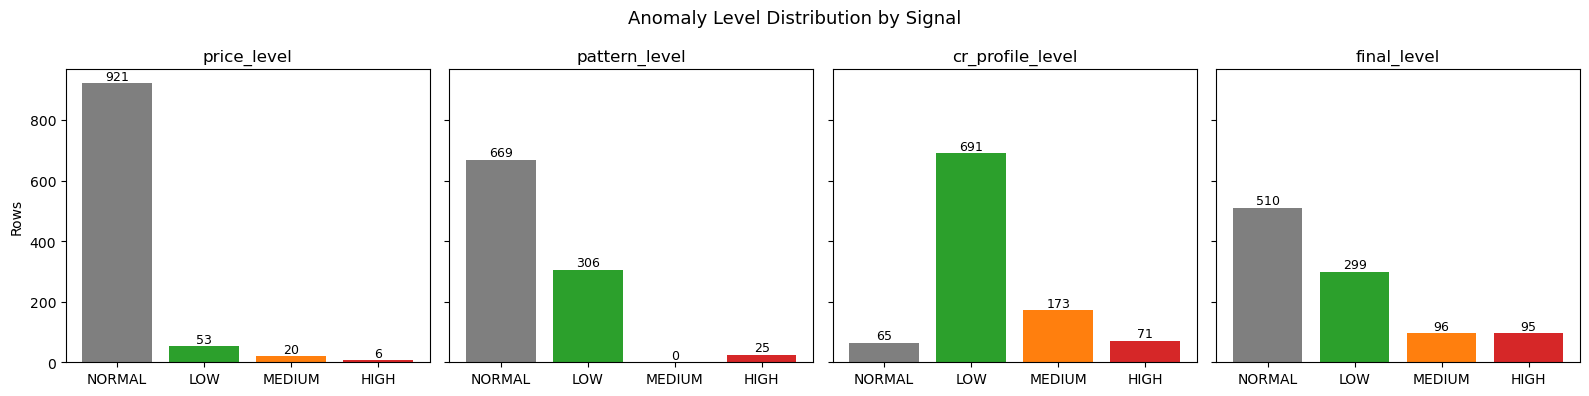


Distribution table:
        price_level  pattern_level  cr_profile_level  final_level
NORMAL          921            669                65          510
LOW              53            306               691          299
MEDIUM           20              0               173           96
HIGH              6             25                71           95


In [65]:
# Side-by-side bar chart: how each level column distributes
LEVEL_ORDER_DISPLAY = ["NORMAL", "LOW", "MEDIUM", "HIGH"]
LEVEL_COLORS        = {"NORMAL": "#7f7f7f", "LOW": "#2ca02c", "MEDIUM": "#ff7f0e", "HIGH": "#d62728"}

level_cols = ["price_level", "pattern_level", "cr_profile_level", "final_level"]

# Build a tidy frame: rows = level, cols = which signal
dist = pd.DataFrame(
    {col: df[col].value_counts() for col in level_cols}
).reindex(LEVEL_ORDER_DISPLAY).fillna(0).astype(int)

# Plot — one panel per signal
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, col in zip(axes, level_cols):
    counts = dist[col]
    colors = [LEVEL_COLORS[lvl] for lvl in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(col)
    ax.set_ylabel("Rows" if col == level_cols[0] else "")
    # Annotate each bar with the count
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha="center", va="bottom", fontsize=9)

fig.suptitle("Anomaly Level Distribution by Signal", fontsize=13)
plt.tight_layout()
plt.show()

# Also print the underlying numbers
print("\nDistribution table:")
print(dist)

---

# PART 6 — Save Output

Final `master_anomalies.csv` — one row per declaration with all signals, sub-scores, sub-levels, the composite final level, and the reason driving it. Designed to be the input for `LLMy.ipynb` (filtered to flagged rows) and `CR_LLM.ipynb` (joined on `active_cr`).

In [66]:
# Column ordering for the saved CSV — grouped logically for readability
keep_cols = [
    # Identifiers and traceability
    "item_id", "declaration_id", "declaration_date", "year", "year_month",

    # Goods and partners
    "hs_code", "hs_clean", "hs6", "hs2", "hs_desc", "commercial_description",
    "active_cr", "trade_type", "regime",
    "country_of_origin", "country_of_export", "country_of_destination",
    "country_of_origin_code", "country_of_export_code", "country_of_destination_code",
    "partner_country_code",

    # Money / weight / quantity
    "uom", "qty_by_uom", "actual_unit_price", "price_basis",
    "local_amount_clean", "invoice_amount_clean", "sup_amount_clean",
    "net_weight_clean", "gross_weight_clean",

    # Price anomaly signals
    "log_actual_unit_price", "median", "mad", "q1", "q3", "iqr",
    "iqr_low", "iqr_high", "iqr_flag",
    "robust_z", "anomaly_score", "price_level",

    # Trade pattern signals
    "partner_count", "partner_probability", "partner_rarity_raw", "partner_rarity_score",
    "route_count", "route_probability", "route_rarity_raw", "route_rarity_score",
    "active_months", "month_mean", "month_std", "month_max",
    "burstiness_raw", "burstiness_score",
    "trade_pattern_score", "pattern_level", "trade_pattern_flag",

    # CR profile signals
    "cr_price_z_own", "cr_price_z_peer", "cr_price_severity",
    "cr_burst_ratio", "cr_burst_severity",
    "cr_hs_months_active", "cr_hs_first_time_in_window", "cr_freq_severity",
    "cr_partner_first_time", "cr_partner_hs_first_time", "cr_partner_rarity",
    "cr_portfolio_distance", "cr_portfolio_severity",
    "cr_profile_score", "cr_profile_level", "cr_profile_flag",

    # Composite
    "final_level", "final_reason", "final_flag",
]

# Drop any cols that aren't present (defensive — different cleaned files may vary)
keep_cols = [c for c in keep_cols if c in df.columns]

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df[keep_cols].to_csv(OUTPUT_PATH, index=False)

print(f"Saved {len(df)} rows × {len(keep_cols)} cols to {OUTPUT_PATH}")
print()
print("Top 10 rows by final_level severity then cr_profile_score:")
df["_sort_key"] = df["final_level"].map(LEVEL_ORDER)
top10 = df.nlargest(10, ["_sort_key", "cr_profile_score"])[
    ["active_cr", "hs6", "declaration_date", "final_level",
     "price_level", "pattern_level", "cr_profile_level"]
]
df = df.drop(columns=["_sort_key"])
print(top10.to_string(index=False))

Saved 1000 rows × 78 cols to C:\Users\fawaz\Desktop\Project\outputs\master_anomalies.csv

Top 10 rows by final_level severity then cr_profile_score:
  active_cr    hs6 declaration_date final_level price_level pattern_level cr_profile_level
CR_HASH_004 102211       2020-01-20        HIGH      NORMAL           LOW             HIGH
CR_HASH_049 102211       2020-01-28        HIGH         LOW        NORMAL             HIGH
CR_HASH_032 851712       2020-02-07        HIGH         LOW        NORMAL             HIGH
CR_HASH_018 610910       2020-02-10        HIGH         LOW        NORMAL             HIGH
CR_HASH_019 100630       2020-02-14        HIGH        HIGH        NORMAL             HIGH
CR_HASH_042 847130       2020-02-16        HIGH      NORMAL        NORMAL             HIGH
CR_HASH_001 847130       2020-02-18        HIGH      NORMAL           LOW             HIGH
CR_HASH_033 392330       2020-02-18        HIGH         LOW        NORMAL             HIGH
CR_HASH_020 901839       2020-02